# Réseaux de neurones avec PyTorch

Les réseaux d'apprentissage profond ont tendance à être très volumineux, avec des dizaines ou des centaines de couches : c'est de là que vient le terme « profond ». Vous pouvez construire l'un de ces réseaux profonds en utilisant uniquement des matrices de poids, comme nous l'avons fait dans le notebook précédent, mais en général, cette approche est très fastidieuse et difficile à mettre en œuvre. PyTorch propose un module pratique, `nn`, qui permet de construire efficacement de grands réseaux de neurones.

In [23]:
# Import necessary packages

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import torch

import helper

import matplotlib.pyplot as plt

Nous allons maintenant construire un réseau plus grand capable de résoudre un problème autrefois difficile : identifier du texte dans une image. Nous utiliserons ici le jeu de données MNIST, composé de chiffres manuscrits en niveaux de gris. Chaque image fait 28x28 pixels ; vous pouvez voir un exemple ci-dessous.

<img src='assets/mnist.png'>

Notre objectif est de construire un réseau de neurones capable de recevoir l'une de ces images et de prédire le chiffre qu'elle contient.

Nous devons d'abord récupérer notre jeu de données. Il est fourni par le paquet `torchvision`. Le code ci-dessous téléchargera le jeu de données MNIST, puis créera pour nous des jeux de données d'entraînement et de test. Ne vous préoccupez pas trop des détails pour le moment : vous en apprendrez davantage plus tard.

In [24]:
# The MNIST datasets are hosted on yann.lecun.com that has moved under CloudFlare protection
# Run this script to enable the datasets download
# Reference: https://github.com/pytorch/vision/issues/1938

import urllib.request

opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)


In [25]:
### Run this cell

from torchvision import datasets, transforms

# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])

# Download and load the training data
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

Les données d'entraînement sont chargées dans `trainloader` et nous en faisons un itérateur avec `iter(trainloader)`. Plus tard, nous l'utiliserons pour parcourir le jeu de données pendant l'entraînement, comme ceci :

```python
for image, label in trainloader:
    ## do things with images and labels
```

Vous remarquerez que j'ai créé le `trainloader` avec une taille de lot de 64 et `shuffle=True`. La taille de lot correspond au nombre d'images que nous obtenons à chaque itération du chargeur de données et que nous faisons passer dans notre réseau ; on parle souvent de *lot*. Quant à `shuffle=True`, cela indique de mélanger le jeu de données chaque fois que nous recommençons à parcourir le chargeur. Mais ici, je récupère seulement le premier lot afin que nous puissions examiner les données. Nous pouvons voir ci-dessous que `images` est simplement un tenseur de taille `(64, 1, 28, 28)`. Il y a donc 64 images par lot, 1 canal de couleur et des images de 28x28 pixels.

In [26]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


Voici à quoi ressemble l'une des images.

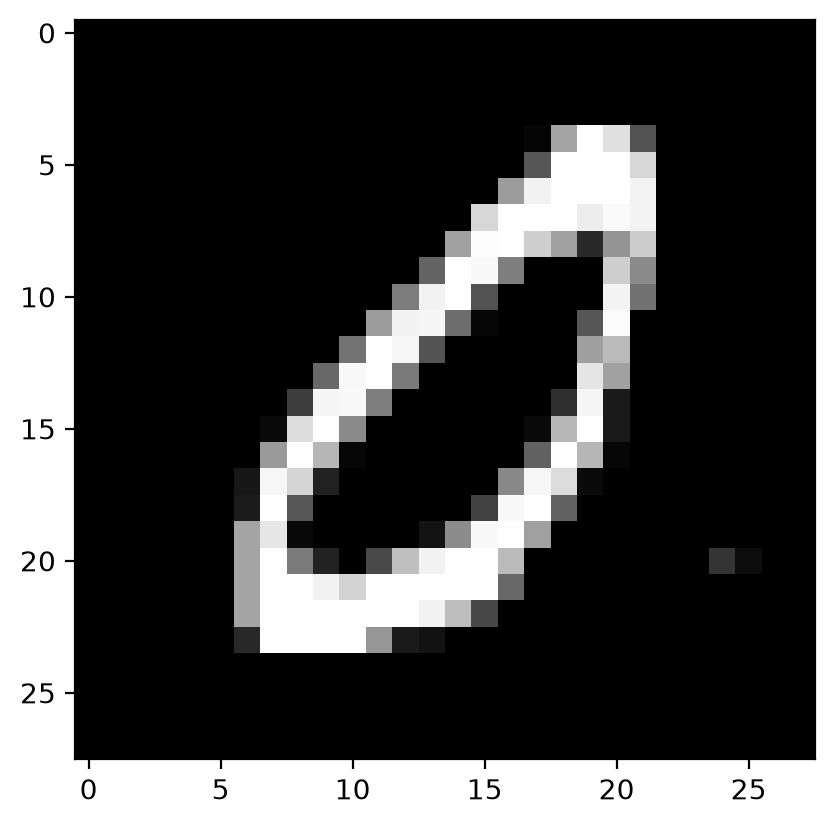

In [27]:
plt.imshow(images[1].numpy().squeeze(), cmap='Greys_r');

Commençons par essayer de construire un réseau simple pour ce jeu de données à l'aide de matrices de poids et de multiplications matricielles. Nous verrons ensuite comment le faire avec le module `nn` de PyTorch, qui offre une méthode bien plus pratique et puissante pour définir des architectures de réseau.

Les réseaux que vous avez vus jusqu'ici sont appelés réseaux *entièrement connectés* ou réseaux *denses*. Chaque unité d'une couche est connectée à chaque unité de la couche suivante. Dans les réseaux entièrement connectés, l'entrée de chaque couche doit être un vecteur à une dimension (qui peut être empilé dans un tenseur 2D sous la forme d'un lot de plusieurs exemples). Or, nos images sont des tenseurs 2D de 28x28 : nous devons donc les convertir en vecteurs 1D. En termes de dimensions, nous devons transformer le lot d'images de forme `(64, 1, 28, 28)` en une forme `(64, 784)`, car 784 est égal à 28 fois 28. Cette opération est généralement appelée *aplatissement* : nous avons aplati les images 2D en vecteurs 1D.

Auparavant, vous avez construit un réseau avec une unité de sortie. Ici, nous avons besoin de 10 unités de sortie, une pour chaque chiffre. Nous voulons que notre réseau prédise le chiffre affiché dans une image ; nous allons donc calculer les probabilités que l'image corresponde à chaque chiffre, ou classe. Nous obtenons ainsi une distribution de probabilité discrète sur les classes (les chiffres), qui nous indique la classe la plus probable pour l'image. Nous avons donc besoin de 10 unités de sortie pour les 10 classes (chiffres). Nous verrons ensuite comment convertir la sortie du réseau en distribution de probabilité.

> **Exercice :** Aplatissez le lot d'images `images`. Construisez ensuite un réseau multicouche avec 784 unités d'entrée, 256 unités cachées et 10 unités de sortie, en utilisant des tenseurs aléatoires pour les poids et les biais. Pour l'instant, utilisez une activation sigmoïde pour la couche cachée. Laissez la couche de sortie sans activation ; nous ajouterons ensuite une activation qui fournira une distribution de probabilité.

In [28]:
## Your solution

# Flatten the images batch from (64, 1, 28, 28) to (64, 784)
images = images.view(images.shape[0], 784)

# Build the network: 784 inputs, 256 hidden units, 10 outputs
weights_input_hidden = torch.randn(784, 256)
bias_input_hidden = torch.randn(256)
weights_hidden_output = torch.randn(256, 10)
bias_hidden_output = torch.randn(10)

hidden = torch.sigmoid(images @ weights_input_hidden + bias_input_hidden)
out = hidden @ weights_hidden_output + bias_hidden_output

Notre réseau possède désormais 10 sorties. Nous souhaitons lui fournir une image et obtenir une distribution de probabilité sur les classes, indiquant la ou les classes auxquelles l'image appartient probablement. Elle ressemble à ceci :
<img src='assets/image_distribution.png' width=500px>

Nous voyons ici que la probabilité de chaque classe est approximativement la même. Cela représente un réseau non entraîné : il n'a encore vu aucune donnée et renvoie donc une distribution uniforme, avec des probabilités égales pour chaque classe.

Pour calculer cette distribution de probabilité, on utilise souvent la fonction [**softmax**](https://en.wikipedia.org/wiki/Softmax_function). Mathématiquement, elle s'écrit :

$$
\Large \sigma(x_i) = \cfrac{e^{x_i}}{\sum_k^K{e^{x_k}}}
$$

Cette fonction ramène chaque entrée $x_i$ entre 0 et 1 et normalise les valeurs afin d'obtenir une véritable distribution de probabilité, dont la somme des probabilités est égale à un.

> **Exercice :** Implémentez une fonction `softmax` qui effectue le calcul softmax et renvoie des distributions de probabilité pour chaque exemple du lot. Notez que vous devrez faire attention aux formes des tenseurs. Si vous avez un tenseur `a` de forme `(64, 10)` et un tenseur `b` de forme `(64,)`, effectuer `a/b` provoquera une erreur, car PyTorch essaiera de réaliser la division sur les colonnes (ce qu'on appelle le *broadcasting*), mais les tailles ne correspondront pas. Pour chacun des 64 exemples, vous ne voulez diviser que par une seule valeur : la somme au dénominateur. `b` doit donc avoir la forme `(64, 1)`. Ainsi, PyTorch divisera les 10 valeurs de chaque ligne de `a` par l'unique valeur de la ligne correspondante de `b`. Faites également attention à la manière dont vous calculez la somme. Vous devrez définir l'argument nommé `dim` dans `torch.sum`. Avec `dim=0`, la somme est calculée sur les lignes, tandis qu'avec `dim=1`, elle est calculée sur les colonnes.

In [29]:
def softmax(x):
    exp_x = torch.exp(x - torch.max(x, dim=1, keepdim=True).values)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

# Here, out should be the output of the network in the previous exercise with shape (64,10)
probabilities = softmax(out)

# Does it have the right shape? Should be (64, 10)
print(probabilities.shape)
# Does it sum to 1?
print(probabilities.sum(dim=1))

torch.Size([64, 10])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


## Construire des réseaux avec PyTorch

PyTorch fournit un module `nn` qui simplifie beaucoup la construction de réseaux. Je vais vous montrer ici comment construire le même réseau que ci-dessus, avec 784 entrées, 256 unités cachées, 10 unités de sortie et une sortie softmax.

In [30]:
from torch import nn

In [31]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Inputs to hidden layer linear transformation
        self.hidden = nn.Linear(784, 256)
        # Output layer, 10 units - one for each digit
        self.output = nn.Linear(256, 10)
        
        # Define sigmoid activation and softmax output 
        self.sigmoid = nn.Sigmoid()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        # Pass the input tensor through each of our operations
        x = self.hidden(x)
        x = self.sigmoid(x)
        x = self.output(x)
        x = self.softmax(x)
        
        return x

Examinons cela étape par étape.

```python
class Network(nn.Module):
```

Ici, nous héritons de `nn.Module`. Associé à `super().__init__()`, cela crée une classe qui suit l'architecture et fournit de nombreuses méthodes et attributs utiles. Il est obligatoire d'hériter de `nn.Module` lorsque vous créez une classe pour votre réseau. Le nom de la classe peut être choisi librement.

```python
self.hidden = nn.Linear(784, 256)
```

Cette ligne crée un module pour une transformation linéaire, $xmathbf{W} + b$, avec 784 entrées et 256 sorties, puis l'affecte à `self.hidden`. Le module crée automatiquement les tenseurs de poids et de biais que nous utiliserons dans la méthode `forward`. Une fois le réseau (`net`) créé, vous pouvez accéder aux tenseurs de poids et de biais avec `net.hidden.weight` et `net.hidden.bias`.

```python
self.output = nn.Linear(256, 10)
```

De même, cela crée une autre transformation linéaire avec 256 entrées et 10 sorties.

```python
self.sigmoid = nn.Sigmoid()
self.softmax = nn.Softmax(dim=1)
```

Ici, j'ai défini les opérations correspondant à l'activation sigmoïde et à la sortie softmax. Définir `dim=1` dans `nn.Softmax(dim=1)` calcule le softmax sur les colonnes.

```python
def forward(self, x):
```

Les réseaux PyTorch créés avec `nn.Module` doivent définir une méthode `forward`. Elle reçoit un tenseur `x` et le fait passer dans les opérations définies dans la méthode `__init__`.

```python
x = self.hidden(x)
x = self.sigmoid(x)
x = self.output(x)
x = self.softmax(x)
```

Ici, le tenseur d'entrée `x` passe dans chaque opération et est réaffecté à `x`. Nous voyons que le tenseur d'entrée passe par la couche cachée, puis par une fonction sigmoïde, ensuite par la couche de sortie et enfin par la fonction softmax. Le nom des variables n'a pas d'importance, tant que les entrées et sorties des opérations correspondent à l'architecture de réseau souhaitée. L'ordre dans lequel vous définissez les éléments dans la méthode `__init__` n'a pas d'importance, mais vous devrez enchaîner correctement les opérations dans la méthode `forward`.

Nous pouvons maintenant créer un objet `Network`.

In [32]:
# Create the network and look at it's text representation
model = Network()
model

Network(
  (hidden): Linear(in_features=784, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=10, bias=True)
  (sigmoid): Sigmoid()
  (softmax): Softmax(dim=1)
)

Vous pouvez définir le réseau de façon un peu plus concise et claire en utilisant le module `torch.nn.functional`. C'est la manière la plus courante de définir les réseaux, car de nombreuses opérations sont de simples fonctions appliquées élément par élément. Nous importons habituellement ce module sous le nom `F`, avec `import torch.nn.functional as F`.

In [33]:
import torch.nn.functional as F

class Network(nn.Module):
    def __init__(self):
        super().__init__()
        # Inputs to hidden layer linear transformation
        self.hidden = nn.Linear(784, 256)
        # Output layer, 10 units - one for each digit
        self.output = nn.Linear(256, 10)
        
    def forward(self, x):
        # Hidden layer with sigmoid activation
        x = F.sigmoid(self.hidden(x))
        # Output layer with softmax activation
        x = F.softmax(self.output(x), dim=1)
        
        return x

### Fonctions d'activation

Jusqu'à présent, nous n'avons examiné que la fonction d'activation sigmoïde, mais en général toute fonction peut servir de fonction d'activation. La seule condition est que, pour qu'un réseau puisse approximer une fonction non linéaire, les fonctions d'activation doivent elles-mêmes être non linéaires. Voici quelques exemples courants : Tanh (tangente hyperbolique) et ReLU (unité linéaire rectifiée).

<img src="assets/activation.png" width=700px>

En pratique, la fonction ReLU est utilisée presque exclusivement comme fonction d'activation pour les couches cachées.

### À vous de construire un réseau

<img src="assets/mlp_mnist.png" width=600px>

> **Exercice :** Créez un réseau avec 784 unités d'entrée, une couche cachée de 128 unités avec une activation ReLU, puis une couche cachée de 64 unités avec une activation ReLU, et enfin une couche de sortie avec une activation softmax, comme illustré ci-dessus. Vous pouvez utiliser une activation ReLU avec le module `nn.ReLU` ou la fonction `F.relu`.

Il est conseillé de nommer vos couches selon leur type de réseau, par exemple `fc` pour représenter une couche entièrement connectée. Dans votre solution, utilisez `fc1`, `fc2` et `fc3` comme noms de couches.

In [34]:
## Your solution here

class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return F.softmax(self.fc3(x), dim=1)

model = Network()

### Initialiser les poids et les biais

Les poids et les autres paramètres sont initialisés automatiquement, mais il est possible de personnaliser leur initialisation. Les poids et les biais sont des tenseurs associés à la couche que vous avez définie ; vous pouvez par exemple les obtenir avec `model.fc1.weight`.

In [35]:
print(model.fc1.weight)
print(model.fc1.bias)

Parameter containing:
tensor([[ 0.0164,  0.0096, -0.0155,  ..., -0.0348, -0.0238, -0.0115],
        [ 0.0201, -0.0189,  0.0049,  ...,  0.0116, -0.0124,  0.0329],
        [-0.0202, -0.0312,  0.0119,  ...,  0.0179,  0.0075, -0.0204],
        ...,
        [ 0.0077, -0.0346, -0.0268,  ...,  0.0162,  0.0071, -0.0345],
        [-0.0194,  0.0019,  0.0112,  ..., -0.0099, -0.0192,  0.0065],
        [ 0.0228, -0.0146, -0.0058,  ...,  0.0220,  0.0068, -0.0323]],
       requires_grad=True)
Parameter containing:
tensor([-0.0347, -0.0125, -0.0184, -0.0354, -0.0314,  0.0339,  0.0352, -0.0329,
         0.0277,  0.0222, -0.0153,  0.0354,  0.0009,  0.0180, -0.0067, -0.0047,
        -0.0088, -0.0186,  0.0009,  0.0355, -0.0009,  0.0233, -0.0294,  0.0229,
        -0.0149,  0.0301,  0.0349, -0.0192, -0.0094,  0.0340,  0.0072, -0.0152,
        -0.0270,  0.0136,  0.0040, -0.0032,  0.0026,  0.0215, -0.0241, -0.0011,
         0.0176,  0.0059, -0.0203,  0.0323, -0.0114, -0.0251, -0.0198, -0.0173,
         0.0183

Pour une initialisation personnalisée, nous voulons modifier ces tenseurs sur place. Ce sont en fait des *Variables* d'autograd ; nous devons donc récupérer les tenseurs réels avec `model.fc1.weight.data`. Une fois les tenseurs obtenus, nous pouvons les remplir avec des zéros (pour les biais) ou des valeurs aléatoires suivant une loi normale.

In [36]:
# Set biases to all zeros
model.fc1.bias.data.fill_(0)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.])

In [37]:
# sample from random normal with standard dev = 0.01
model.fc1.weight.data.normal_(std=0.01)

tensor([[-0.0002,  0.0169, -0.0261,  ..., -0.0031, -0.0194, -0.0278],
        [ 0.0140, -0.0019,  0.0079,  ...,  0.0081, -0.0047, -0.0084],
        [-0.0030, -0.0113, -0.0089,  ...,  0.0075, -0.0032, -0.0090],
        ...,
        [ 0.0059,  0.0120,  0.0089,  ...,  0.0208, -0.0119, -0.0106],
        [ 0.0025, -0.0002,  0.0108,  ..., -0.0174, -0.0030, -0.0068],
        [ 0.0022, -0.0117, -0.0065,  ..., -0.0123, -0.0049,  0.0061]])

### Propagation avant

Maintenant que nous avons un réseau, voyons ce qui se passe lorsque nous lui transmettons une image.

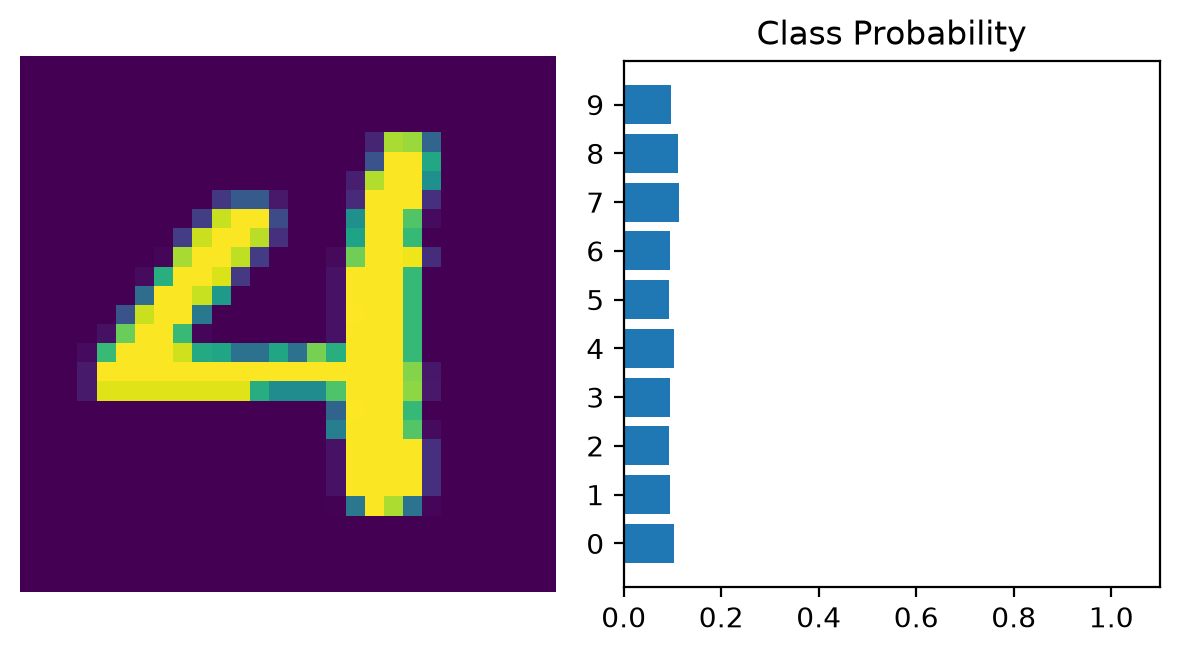

In [38]:
# Grab some data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Resize images into a 1D vector
images = images.view(images.shape[0], 1, 784)

# Forward pass through the network
img_idx = 0
ps = model(images[img_idx])

img = images[img_idx]
helper.view_classify(img.view(1, 28, 28), ps)

Comme vous pouvez le voir ci-dessus, notre réseau n'a pratiquement aucune idée du chiffre représenté. C'est parce que nous ne l'avons pas encore entraîné : tous les poids sont aléatoires !

### Utiliser `nn.Sequential`

PyTorch offre une manière pratique de construire ce type de réseau, dans lequel un tenseur passe séquentiellement à travers des opérations : `nn.Sequential` ([documentation](https://pytorch.org/docs/master/nn.html#torch.nn.Sequential)). Voici comment l'utiliser pour construire le réseau équivalent :

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): Softmax(dim=1)
)


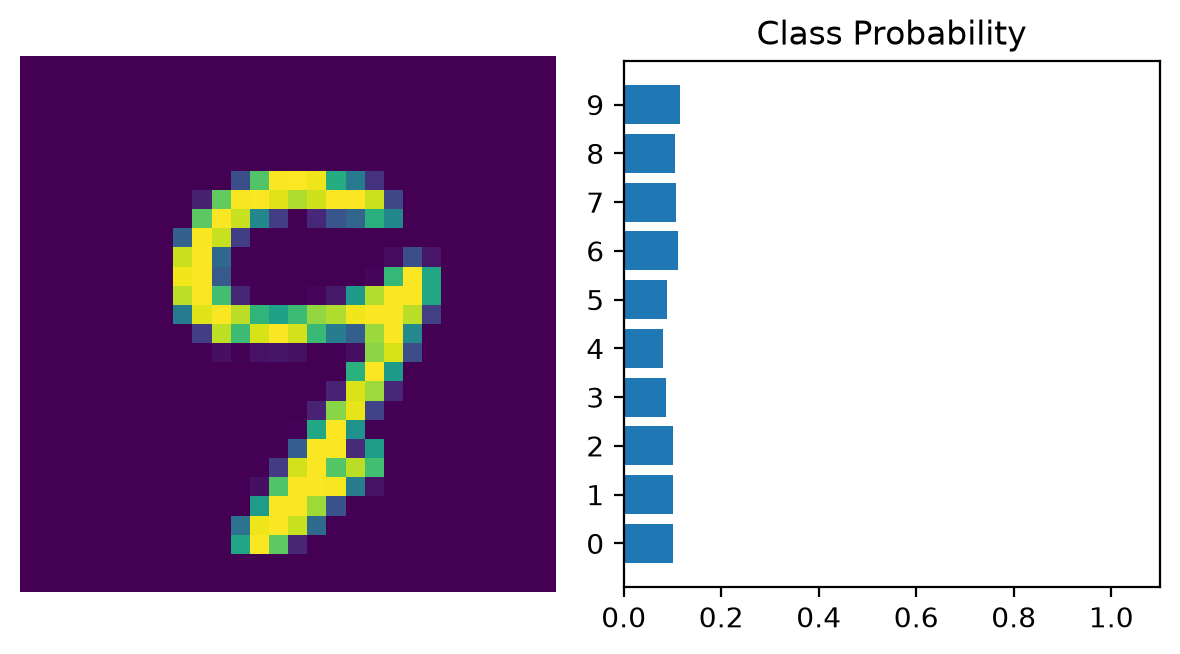

In [39]:
# Hyperparameters for our network
input_size = 784
hidden_sizes = [128, 64]
output_size = 10

# Build a feed-forward network
model = nn.Sequential(nn.Linear(input_size, hidden_sizes[0]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[0], hidden_sizes[1]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[1], output_size),
                      nn.Softmax(dim=1))
print(model)

# Forward pass through the network and display output
images, labels = next(iter(trainloader))
images.resize_(images.shape[0], 1, 784)
ps = model.forward(images[0,:])
helper.view_classify(images[0].view(1, 28, 28), ps)

Ici, notre modèle est identique au précédent : 784 unités d'entrée, une couche cachée de 128 unités avec activation ReLU, une couche cachée de 64 unités, une autre ReLU, puis une couche de sortie de 10 unités et une sortie softmax.

Les opérations sont accessibles en fournissant l'indice approprié. Par exemple, pour obtenir la première opération `Linear` et examiner les poids, vous utiliseriez `model[0]`.

In [40]:
print(model[0])
model[0].weight

Linear(in_features=784, out_features=128, bias=True)


Parameter containing:
tensor([[ 0.0136, -0.0087, -0.0008,  ..., -0.0062, -0.0241,  0.0226],
        [ 0.0304, -0.0222, -0.0174,  ...,  0.0341, -0.0249,  0.0119],
        [-0.0148,  0.0183, -0.0262,  ...,  0.0046,  0.0103,  0.0009],
        ...,
        [-0.0142, -0.0125,  0.0210,  ...,  0.0186,  0.0347, -0.0271],
        [-0.0321,  0.0125, -0.0142,  ...,  0.0109, -0.0036,  0.0199],
        [ 0.0039, -0.0021, -0.0124,  ..., -0.0064,  0.0239,  0.0222]],
       requires_grad=True)

Vous pouvez également transmettre un `OrderedDict` afin de nommer les différentes couches et opérations, plutôt que d'utiliser des nombres entiers successifs. Notez que les clés du dictionnaire doivent être uniques : *chaque opération doit donc avoir un nom différent* .

In [41]:
from collections import OrderedDict
model = nn.Sequential(OrderedDict([
                      ('fc1', nn.Linear(input_size, hidden_sizes[0])),
                      ('relu1', nn.ReLU()),
                      ('fc2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
                      ('relu2', nn.ReLU()),
                      ('output', nn.Linear(hidden_sizes[1], output_size)),
                      ('softmax', nn.Softmax(dim=1))]))
model

Sequential(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)

Vous pouvez maintenant accéder aux couches soit par un entier, soit par leur nom.

In [42]:
print(model[0])
print(model.fc1)

Linear(in_features=784, out_features=128, bias=True)
Linear(in_features=784, out_features=128, bias=True)


Dans le prochain notebook, nous verrons comment entraîner un réseau de neurones pour prédire avec précision les chiffres apparaissant dans les images MNIST.